#Paper utilizado:

[1] M. Bahaghighat, M. Ghasemi y F. Ozen,
“A high-accuracy phishing website detection method based on machine learning,”
Journal of Information Security and Applications,
vol. 77,
art. 103553,
2023.
doi: 10.1016/j.jisa.2023.103553.
Available: https://www.sciencedirect.com/science/article/pii/S2214212623001370

#Limpieza de datos

En este colab se realizará la limpieza del set de datos para el entrenamiento de un modelo de inteligencia artificial. El dataset que se está usando es el de Abdelhamid, N. (2014). Website Phishing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5B301.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import, según la documentación de UC Irvine

In [63]:
pip install ucimlrepo

In [64]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
website_phishing = fetch_ucirepo(id=379)

# data (as pandas dataframes)
X = website_phishing.data.features
y = website_phishing.data.targets

# metadata
print(website_phishing.metadata)

# variable information
print(website_phishing.variables)


{'uci_id': 379, 'name': 'Website Phishing', 'repository_url': 'https://archive.ics.uci.edu/dataset/379/website+phishing', 'data_url': 'https://archive.ics.uci.edu/static/public/379/data.csv', 'abstract': '\n\n', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1353, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2014, 'last_updated': 'Thu Mar 21 2024', 'dataset_doi': '10.24432/C5B301', 'creators': ['Neda Abdelhamid'], 'intro_paper': {'ID': 440, 'type': 'NATIVE', 'title': 'Phishing detection based Associative Classification data mining', 'authors': 'Neda Abdelhamid, A. Ayesh, F. Thabtah', 'venue': 'Expert systems with applications', 'year': 2014, 'journal': None, 'DOI': '10.1016/j.eswa.2014.03.019', 'URL': 'https://www.semanticscholar.org/paper/867e2293e9780b729705b4ba48d6b1

El dataset ya menciona que no hay valores faltantes, sin embargo aún así haré el análisis de valores faltantes junto con otros análisis para verificar la usabilidad de los datos más adelante.

Modificar la importación para manejarlo como pandas: ¿por qué? porque estoy más familiarizado y me gusta para analizar los datos.

In [65]:
#pasar a pandas
X = pd.DataFrame(website_phishing.data.features)
y = pd.DataFrame(website_phishing.data.targets)

# estoy juntando el target con el resto de datos en una tabla (más adelante se vuelven a separar)
df = pd.concat([X, y], axis=1)

print(df.head())

   SFH  popUpWindow  SSLfinal_State  Request_URL  URL_of_Anchor  web_traffic  \
0    1           -1               1           -1             -1            1   
1   -1           -1              -1           -1             -1            0   
2    1           -1               0            0             -1            0   
3    1            0               1           -1             -1            0   
4   -1           -1               1           -1              0            0   

   URL_Length  age_of_domain  having_IP_Address  Result  
0           1              1                  0       0  
1           1              1                  1       1  
2          -1              1                  0       1  
3           1              1                  0       0  
4          -1              1                  0       1  


#Aqui podemos ver que tenemos 9 columnas de features y una de target que es la columna "Result"
También podemos observar que los valores son enteros que van de 0 a 1 y de -1 a 1.

Por ello asumo que los valores de 0 a 1 son booleanos. Y que las otras columnas siguen el mismo formato que Result donde los valores de -1 son categorizados como algo negativo, el 1 como algo positivo y el 0 como algo sospechoso.




In [66]:
df.shape

(1353, 10)

Haré un .info() ya que este nos dice el tipo de dato de cada una de nuestras features.

Dos columnas distintas pueden tener tipos de datos distintos, sin embargo no pueden haber dos tipos de datos en una misma columna.

In [67]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   SFH                1353 non-null   int64
 1   popUpWindow        1353 non-null   int64
 2   SSLfinal_State     1353 non-null   int64
 3   Request_URL        1353 non-null   int64
 4   URL_of_Anchor      1353 non-null   int64
 5   web_traffic        1353 non-null   int64
 6   URL_Length         1353 non-null   int64
 7   age_of_domain      1353 non-null   int64
 8   having_IP_Address  1353 non-null   int64
 9   Result             1353 non-null   int64
dtypes: int64(10)
memory usage: 105.8 KB
None


Todas las columnas tienen un solo tipo de dato (int64). Por ello podemos asumir que no hay anomalías en nuestro set de datos en el tipo de dato registrado. De lo contrario, se debería de cambiar el tipo de dato de las filas mal registradas en caso de ser posible o eliminar las filas (En este problema no veo muy recomendable rellenar espacios faltantes con valores aproximados o promedio ya que son clasificaciones todas las columnas).

#El siguiente describe() nos da estadísticas generales del set de datos. Esto nos ayuda a detectar otras anomalías en los datos: Por ejemplo cuando hay un valor muy grande que pueda afectar los cálculos.

Como mencioné, parece que en este dataset todos los datos son binarios o son -1, 0 y 1. Por ello los mínimos y máximos no deberían de exceder estos valores.

En realidad esperamos que todos los valores se encuentren en estos rangos excepto por la cuenta en lo que esperamos que todos los valores tengan la misma cuenta que el df.shape. Si es menor significa que tenemos valores faltantes y debemos de decidir cómo tratarlos.

Me parece curioso que en age of domain no tengamos valores enteros sino ya la interpretación de si el sitio es sospechosamente reciente.

De igual forma me parece que el único booleano del set de datos es el de si tiene una dirección IP donde asumo que el 1 representa algo malo pues no hay un dominio.

In [68]:
df.describe()

,SFH,popUpWindow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address,Result
count,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000
mean,0.237990,-0.258684,0.327421,-0.223208,-0.025129,0.000000,-0.053215,0.219512,0.114560,-0.113821
std,0.916389,0.679072,0.822193,0.799682,0.936262,0.806776,0.762552,0.975970,0.318608,0.954773
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000
25%,-1.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-1.000000
75%,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


A partir de la tebla previa podemos asumir que todos los valores se encuentran bien registrados y que no contamos con valores faltantes.

Aún así, realizaré un script de limpieza simulando que sí hay valores faltantes en las columnas. Me parece valioso tener el código que sirve para revisar y corregir si hay valores faltantes

#Limpieza de datos



In [69]:
conteo_no_nulos = df.count().sort_values(ascending=False)
total_filas = len(df)

resumen_completitud = pd.DataFrame({
    "No_nulos": conteo_no_nulos,
    "Total_filas": total_filas,
    "Porcentaje_completitud (%)": round(conteo_no_nulos / total_filas * 100, 2)
})

resumen_completitud = resumen_completitud.sort_values(by="Porcentaje_completitud (%)", ascending=False)

print("Resumen de completitud de columnas:")
display(resumen_completitud)

umbral = 70
columnas_bajas = resumen_completitud[resumen_completitud["Porcentaje_completitud (%)"] < umbral]
if not columnas_bajas.empty:
    print(f"\n Columnas con menos del {umbral}% de completitud:")
    display(columnas_bajas)
else:
    print(f"\nTodas las columnas tienen al menos {umbral}% de completitud.")


Resumen de completitud de columnas:


,No_nulos,Total_filas,Porcentaje_completitud (%)
SFH,1353,1353,100.0
popUpWindow,1353,1353,100.0
SSLfinal_State,1353,1353,100.0
Request_URL,1353,1353,100.0
URL_of_Anchor,1353,1353,100.0
web_traffic,1353,1353,100.0
URL_Length,1353,1353,100.0
age_of_domain,1353,1353,100.0
having_IP_Address,1353,1353,100.0
Result,1353,1353,100.0



Todas las columnas tienen al menos 70% de completitud.


En el código previo se marcan las columnas que tengan menos del 70% de sus filas llenas ya que pueden llegar a ser problemáticas para determinar si vale la pena eliminar las filas o directamente la columna.


##Identificar valores únicos

El siguiente código puede ser medio redundante porque describe() ya me dice los valores únicos de las columnas de tipo object.

Sin embargo el código me permite hacer lo mismo incluso cuando no son objetos.

Con esto puedo identificar si alguna columna no me es útil (cuando todas o casi todas las instancias tienen el mismo valor)

In [70]:
dfejemplo = pd.DataFrame({
    "color": ["rojo", "azul", "rojo", "verde"]
})

print(dfejemplo.describe(include='object'))

       color
count      4
unique     3
top     rojo
freq       2


In [71]:
valores_unicos = df.nunique().sort_values()

resumen_unicos = pd.DataFrame({
    "Valores_únicos": valores_unicos,
    "Total_filas": len(df),
    "Porcentaje_únicos (%)": round(valores_unicos / len(df) * 100, 3)
})

# Mostrar de menor a mayor (columnas menos variables primero)
print("Cantidad de valores únicos por columna:")
display(resumen_unicos)

# === (Opcional) Mostrar solo columnas con muy poca variabilidad ===
umbral_unicos = 2  # por ejemplo, columnas con solo 1 o 2 valores únicos
columnas_poco_utiles = resumen_unicos[resumen_unicos["Valores_únicos"] <= umbral_unicos]

if not columnas_poco_utiles.empty:
    print(f"\n !!!!!!!!!!!!! Columnas con {umbral_unicos} o menos valores únicos:")
    display(columnas_poco_utiles)
else:
    print(f"\n Todas las columnas tienen más de {umbral_unicos} valores únicos.")


Cantidad de valores únicos por columna:


,Valores_únicos,Total_filas,Porcentaje_únicos (%)
age_of_domain,2,1353,0.148
having_IP_Address,2,1353,0.148
SSLfinal_State,3,1353,0.222
SFH,3,1353,0.222
Request_URL,3,1353,0.222
URL_of_Anchor,3,1353,0.222
web_traffic,3,1353,0.222
popUpWindow,3,1353,0.222
URL_Length,3,1353,0.222
Result,3,1353,0.222



 !!!!!!!!!!!!! Columnas con 2 o menos valores únicos:


,Valores_únicos,Total_filas,Porcentaje_únicos (%)
age_of_domain,2,1353,0.148
having_IP_Address,2,1353,0.148


Algo interesante que sale de aquí es que age of domain solo tiene dos valores a pesar de no ser un booleano.

##limpieza de columnas

El siguiente código sirve para eliminar columnas que sean muy problemáticas o que no aporten valor

In [72]:
df.shape

(1353, 10)

In [73]:
# Lista de columnas a eliminar, No hay que eliminar ninguna
columnas_a_eliminar = [
    "Nombre de columna a eliminar"
]

# Eliminar las columnas (si existen)
df_limpio = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])

print("Columnas eliminadas correctamente.")

df_limpio.shape


Columnas eliminadas correctamente.


(1353, 10)

##Preparación para xgboost

Como es un problema de clasificación, estoy pensando en la posibilidad de utilizar xgboost. Sin embargo, a xgboost no le gusta que sea -1, 0, 1. Por lo que se cambia a 0, 1, 2. Esto no afecta el resultado de ninguno de los modelos ya que solo estamos dando valores distintos a una clasificación.

In [74]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_limpio["Result"] = label_encoder.fit_transform(df_limpio["Result"])

# En el siguiente código con dropna, se eliminan las filas con valores vacios. En este caso no aplica ya que no hay valores vacios

In [75]:
filas_antes = len(df_limpio)

df_limpio = df_limpio.dropna()

filas_despues = len(df_limpio)
filas_eliminadas = filas_antes - filas_despues

print(f" Se eliminaron {filas_eliminadas} filas con datos vacíos.")
print(f" Total antes: {filas_antes} → Total después: {filas_despues}")

df_limpio.to_excel("/content/WebPhish.xlsx", index=False)
print("Archivo final guardado como 'WebPhish.xlsx'")

 Se eliminaron 0 filas con datos vacíos.
 Total antes: 1353 → Total después: 1353
Archivo final guardado como 'WebPhish.xlsx'


In [76]:
df_limpio.shape

(1353, 10)

#Separación de dataset en train, test y validate

En el dataset tenemos:
- 702 sitios phishing
- 548 sitios legítimos
- 103 sitios sospechosos

Esto nos da suficients datos de sitios legítimos y de sitios de phishing, pero puede estar algo justo para la identificación de sitios sospechosos.

Aún así decidí dejar un split de 80 20 en train y test. Esto nos deja al menos 20 ejemplos de sitios sospechosos y 80 para el entrenamiento. Sin embargo como también el entrenamiento se tiene que dividir, puede ser algo difícil entrenar al modelo para distinguir los sitios sospechosos.

##En las posibles mejoras futuras se podría tratar de aumentar artificialmente la proporciónn de sitios sospechosos por medio de una herramienta como SMOTE (Synthetic Minority Oversampling Technique).



In [77]:
from sklearn.model_selection import train_test_split
#Ahora sí separamos los datos
X = df_limpio.drop("Result", axis=1)
y = df_limpio["Result"]

X_train80, X_test, y_train80, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,

    #permite mantener proporciones de y en la separación
    stratify=y
)

In [78]:
X_train, X_validate, y_train, y_validate = train_test_split(
    X_train80,
    y_train80,
    test_size=0.2,
    random_state=42,

    stratify=y_train80
)

#Tratamiento de datos

Código para agregar algunas columnas que pueden servir para el análisis y cambio en los formatos de datos.

Para este problema como todas las columnas son

##Escalamiento (one hot encoding)

In [79]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_validate_encoded = pd.get_dummies(X_validate)


print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_validate_encoded.shape)

(865, 9)
(271, 9)
(217, 9)


#Aquí me di cuenta que mi encoding no hizo nada porque dummies no cambia variables numericas, sino categoricas, en el siguiente código fuerzo a que se traten como categoricas.

In [80]:
X_train_encoded = pd.get_dummies(
    X_train.astype("category")
)

X_test_encoded = pd.get_dummies(
    X_test.astype("category")
)

X_validate_encoded = pd.get_dummies(
    X_validate.astype("category")
)

In [81]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_validate_encoded.shape)

(865, 25)
(271, 25)
(217, 25)


Ambas columnas deberían ser iguales, por ello hay que alinearlas, ya que si no no se puede predecir. En este caso sí son iguales.

Lo que hacemos es si en test hay (azul/amarillo) y en train hay (azul/rojo), vamos a tener en ambos (azul/amarillo/rojo)

In [82]:
# Alinear columnas
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

X_train_encoded, X_validate_encoded = X_train_encoded.align(
    X_validate_encoded,
    join='left',
    axis=1,
    fill_value=0
)

print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_validate_encoded.shape)

(865, 25)
(271, 25)
(217, 25)


In [83]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 865 entries, 174 to 294
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   SFH_-1               865 non-null    bool 
 1   SFH_0                865 non-null    bool 
 2   SFH_1                865 non-null    bool 
 3   popUpWindow_-1       865 non-null    bool 
 4   popUpWindow_0        865 non-null    bool 
 5   popUpWindow_1        865 non-null    bool 
 6   SSLfinal_State_-1    865 non-null    bool 
 7   SSLfinal_State_0     865 non-null    bool 
 8   SSLfinal_State_1     865 non-null    bool 
 9   Request_URL_-1       865 non-null    bool 
 10  Request_URL_0        865 non-null    bool 
 11  Request_URL_1        865 non-null    bool 
 12  URL_of_Anchor_-1     865 non-null    bool 
 13  URL_of_Anchor_0      865 non-null    bool 
 14  URL_of_Anchor_1      865 non-null    bool 
 15  web_traffic_-1       865 non-null    bool 
 16  web_traffic_0        865 non-

In [84]:
X_train_encoded.describe(include='all').T

,count,unique,top,freq
SFH_-1,865,2,False,587
SFH_0,865,2,False,776
SFH_1,865,2,True,498
popUpWindow_-1,865,2,False,520
popUpWindow_0,865,2,False,455
popUpWindow_1,865,2,False,755
SSLfinal_State_-1,865,2,False,676
SSLfinal_State_0,865,2,False,672
SSLfinal_State_1,865,2,True,483
Request_URL_-1,865,2,False,464


#Función para evaluar los modelos:

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def get_metrics(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    return accuracy, precision, recall, f1

#Entrenamiento de datos

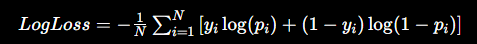

In [86]:
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier

log_model = SGDClassifier(
    loss='log_loss',
    random_state=42
)

epochs = 30

train_acc = []
test_acc = []
validate_acc = []

train_f1 = []
test_f1 = []
validate_f1 = []

for epoch in range(epochs):

    log_model.partial_fit(
        X_train_encoded,
        y_train,
        classes=y_train.unique()
    )

    # Predicciones
    y_train_pred = log_model.predict(X_train_encoded)
    y_test_pred = log_model.predict(X_test_encoded)
    y_validate_pred = log_model.predict(X_validate_encoded)

    # Métricas
    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)
    validate_metrics = get_metrics(y_validate, y_validate_pred)

    # Accuracy
    train_acc.append(train_metrics[0])
    test_acc.append(test_metrics[0])
    validate_acc.append(validate_metrics[0])

    # F1
    train_f1.append(train_metrics[3])
    test_f1.append(test_metrics[3])
    validate_f1.append(validate_metrics[3])

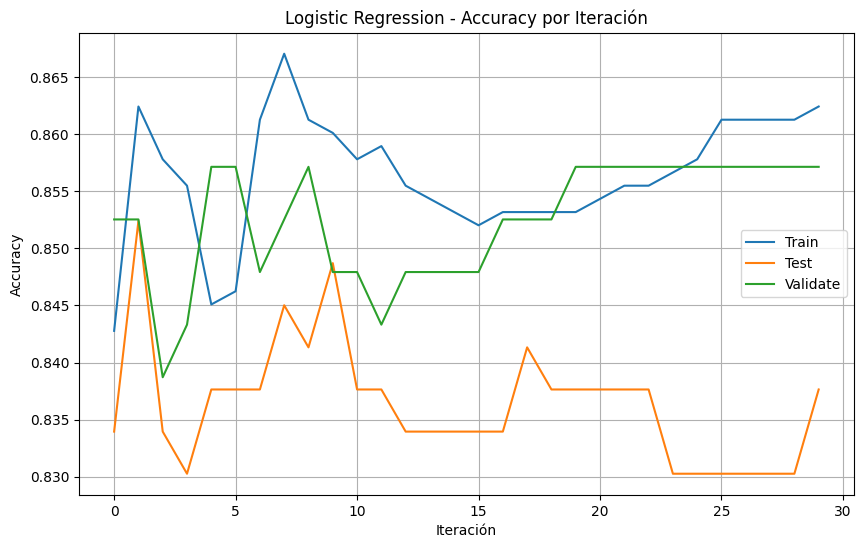

In [87]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.plot(train_acc, label='Train')
plt.plot(test_acc, label='Test')
plt.plot(validate_acc, label='Validate')

plt.xlabel('Iteración')
plt.ylabel('Accuracy')
plt.title('Logistic Regression - Accuracy por Iteración')

plt.legend()
plt.grid()

plt.show()

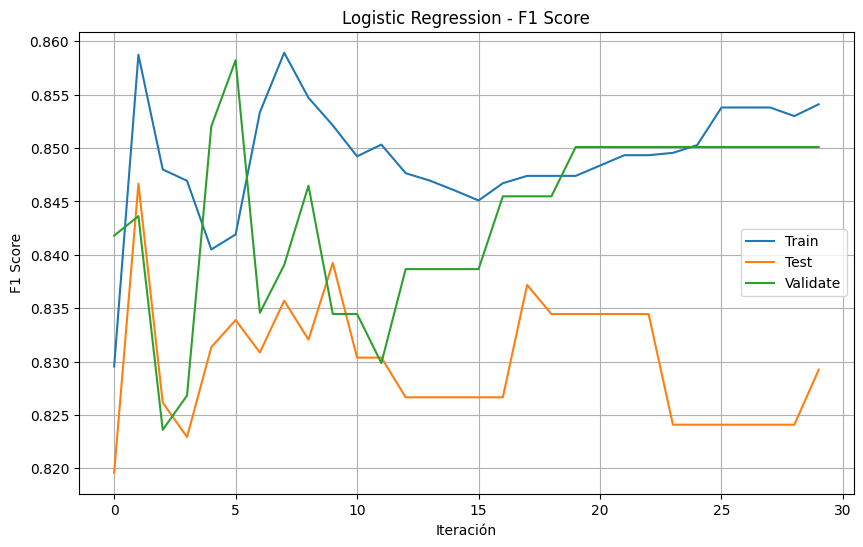

In [88]:
plt.figure(figsize=(10,6))

plt.plot(train_f1, label='Train')
plt.plot(test_f1, label='Test')
plt.plot(validate_f1, label='Validate')

plt.xlabel('Iteración')
plt.ylabel('F1 Score')
plt.title('Logistic Regression - F1 Score')

plt.legend()
plt.grid()

plt.show()

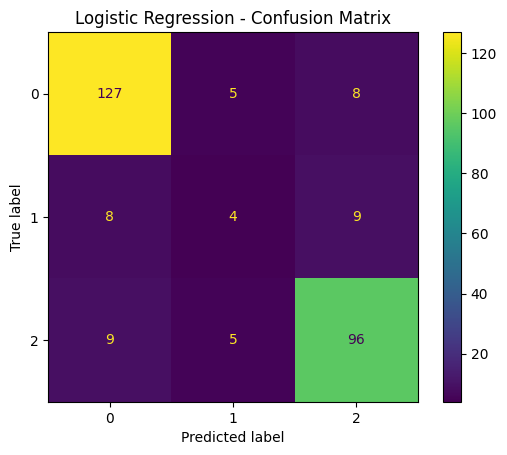

In [89]:
y_pred_log = log_model.predict(X_test_encoded)

cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log
)

disp.plot()

plt.title('Logistic Regression - Confusion Matrix')

plt.show()

Aqui podemos ver que el modelo tiene mucho problema con la clasificación de sitios sospechosos a pesar de que es bueno para detectar phishing y sitios seguros.

#Random forest

### Hiperparámetros:
n_estimators (estimator): número de árboles

max_depth: a mayor profundidad permite encontrar aprender patrones más complejos pero puede causar overfitting

min_samples_leaf: Mínimo de muestras por hoja. Al aumentar disminuye el overfitting

In [90]:
from sklearn.ensemble import RandomForestClassifier

train_acc_rf = []
test_acc_rf = []
validate_acc_rf = []

train_f1_rf = []
test_f1_rf = []
validate_f1_rf = []

estimators_range = range(1, 101)

for n in estimators_range:

    rf_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        max_depth=None,
        min_samples_leaf=1

    )

    rf_model.fit(X_train_encoded, y_train)

    y_train_pred = rf_model.predict(X_train_encoded)
    y_test_pred = rf_model.predict(X_test_encoded)
    y_validate_pred = rf_model.predict(X_validate_encoded)

    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)
    validate_metrics = get_metrics(y_validate, y_validate_pred)

    # Accuracy
    train_acc_rf.append(train_metrics[0])
    test_acc_rf.append(test_metrics[0])
    validate_acc_rf.append(validate_metrics[0])

    # F1
    train_f1_rf.append(train_metrics[3])
    test_f1_rf.append(test_metrics[3])
    validate_f1_rf.append(validate_metrics[3])

###Nota:
Las siguientes gráficas no son de iteraciones sino de muchos modelos de random forest con diferentes números de árboles

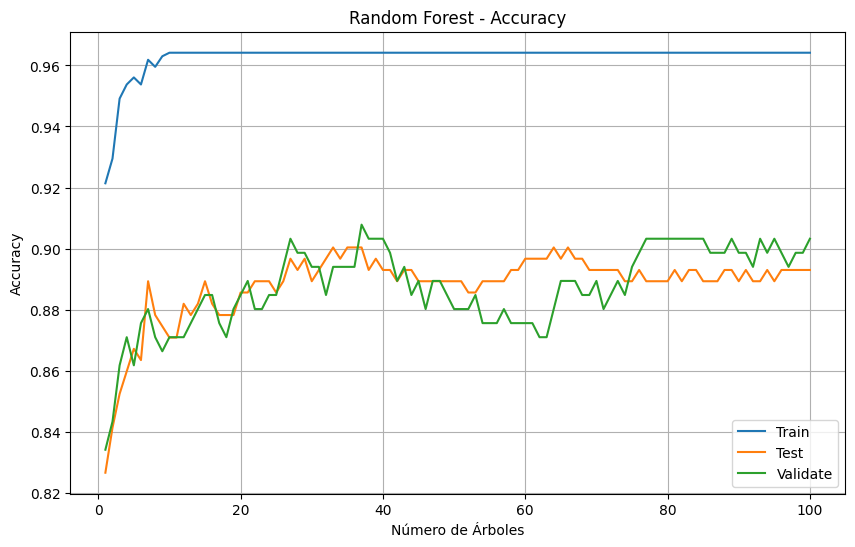

In [91]:
plt.figure(figsize=(10,6))

plt.plot(estimators_range, train_acc_rf, label='Train')
plt.plot(estimators_range, test_acc_rf, label='Test')
plt.plot(estimators_range, validate_acc_rf, label='Validate')

plt.xlabel('Número de Árboles')
plt.ylabel('Accuracy')
plt.title('Random Forest - Accuracy')

plt.legend()
plt.grid()

plt.show()

Esta gráfica muestra algo de overfitting, sin embargo los resultados siguen siendo decentes.

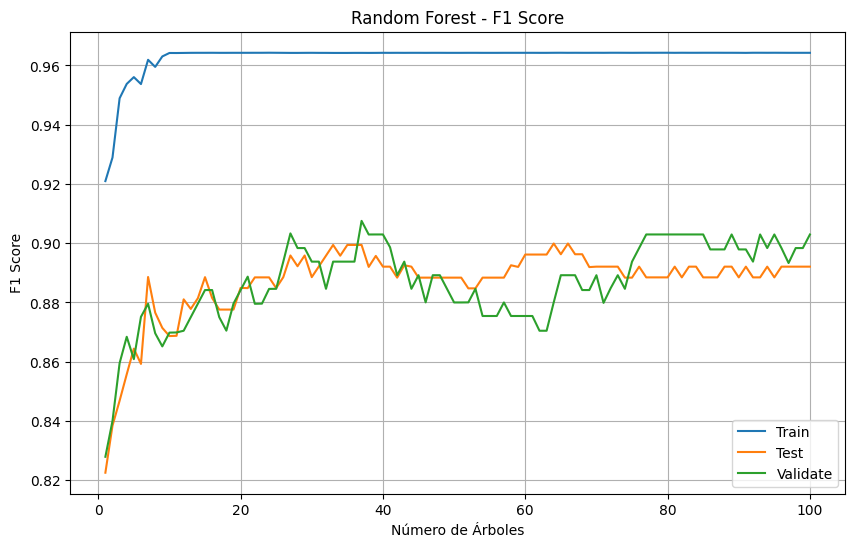

In [92]:
plt.figure(figsize=(10,6))

plt.plot(estimators_range, train_f1_rf, label='Train')
plt.plot(estimators_range, test_f1_rf, label='Test')
plt.plot(estimators_range, validate_f1_rf, label='Validate')

plt.xlabel('Número de Árboles')
plt.ylabel('F1 Score')
plt.title('Random Forest - F1 Score')

plt.legend()
plt.grid()

plt.show()

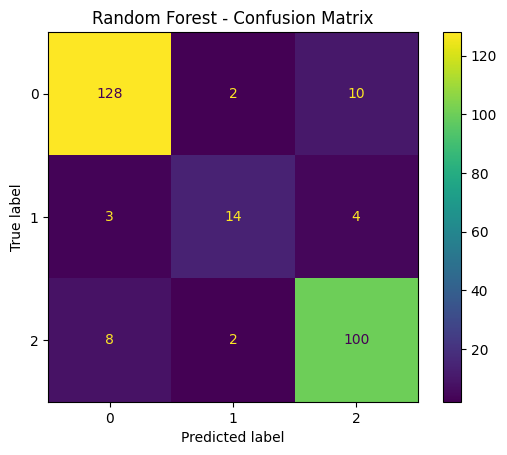

In [93]:
y_pred_rf = rf_model.predict(X_test_encoded)

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title('Random Forest - Confusion Matrix')

plt.show()

Con este otro tipo de modelo, vemos que tiene mucho mejores resultados al identificar los sitios sospechosos.

#XGBClassifier

### Hiperparámetros:
n_estimators: Cantidad de árboles secuenciales.

learning_rate: mientras más grande sea aprende más rápido con más riesgo de overfitting

max_depth: Profundidad máxima de cada árbol. A mayor profundidad entiende patrones más complejos y aumenta overfitting

objective='multi:softmax' Le dice al xgboost que son más de dos clases

eval_metric='mlogloss': Métrica utilizada durante entrenamiento.




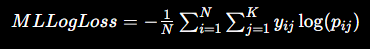

Softmax le asigna una probabilidad a cada clase.

In [94]:
from xgboost import XGBClassifier

num_classes = len(y_train.unique())

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

eval_set = [
    (X_train_encoded, y_train),
    (X_test_encoded, y_test),
    (X_validate_encoded, y_validate)
]

xgb_model.fit(
    X_train_encoded,
    y_train,
    eval_set=eval_set,
    verbose=False
)

results = xgb_model.evals_result()

##Nota:
La siguiente gráfica muestra como avanza el loss en el modelo entrenado

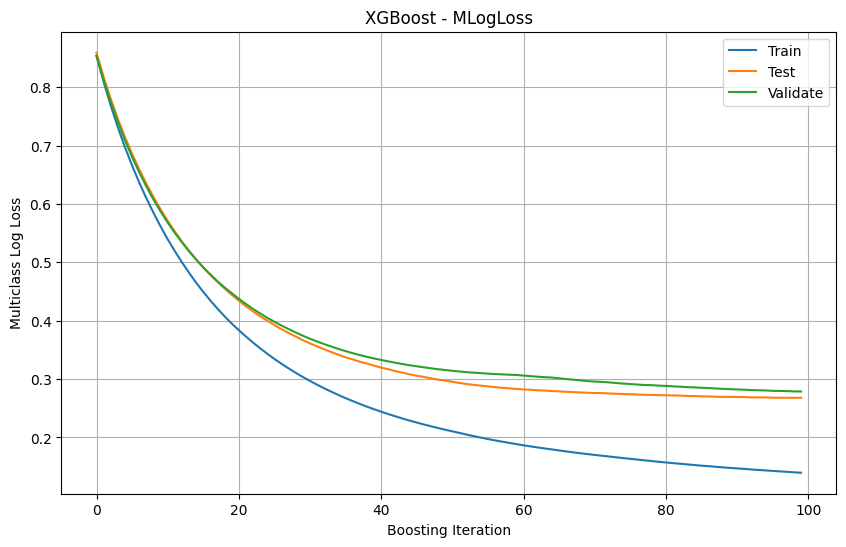

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    results['validation_0']['mlogloss'],
    label='Train'
)

plt.plot(
    results['validation_1']['mlogloss'],
    label='Test'
)

plt.plot(
    results['validation_2']['mlogloss'],
    label='Validate'
)

plt.xlabel('Boosting Iteration')
plt.ylabel('Multiclass Log Loss')
plt.title('XGBoost - MLogLoss')

plt.legend()
plt.grid()

plt.show()

In [96]:
y_predtest_xgb = xgb_model.predict(
    X_test_encoded
)

In [97]:
y_predval_xgb = xgb_model.predict(
    X_validate_encoded
)

In [98]:
y_predtrain_xgb = xgb_model.predict(
    X_train_encoded
)

##Test

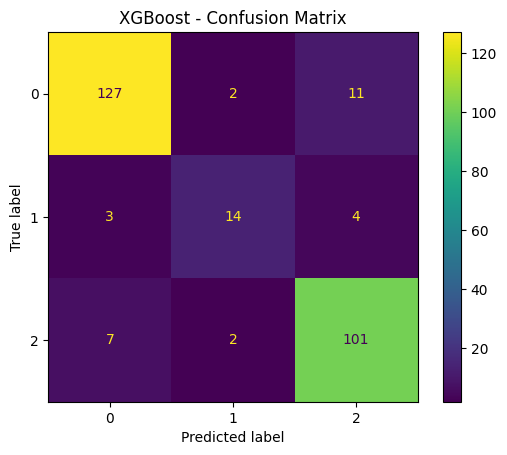

In [99]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    y_predtest_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "XGBoost - Confusion Matrix"
)

plt.show()

##Val

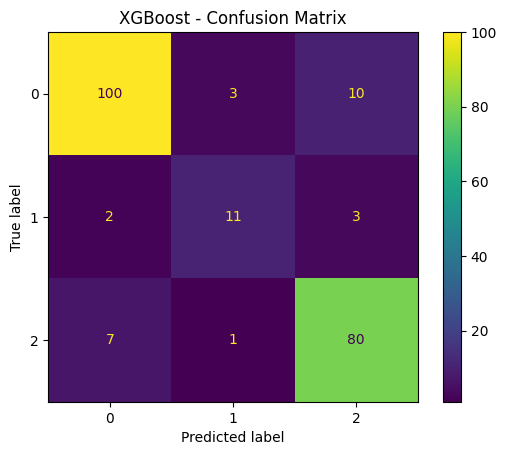

In [100]:
cm = confusion_matrix(
    y_validate,
    y_predval_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "XGBoost - Confusion Matrix"
)

plt.show()

##Train

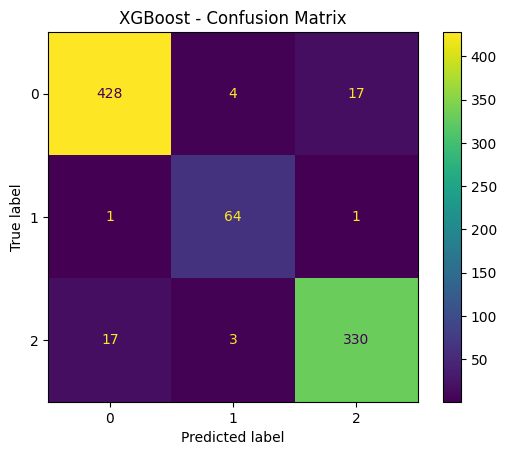

In [101]:
cm = confusion_matrix(
    y_train,
    y_predtrain_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "XGBoost - Confusion Matrix"
)

plt.show()

##Review de XGBOOST



In [102]:
from sklearn.metrics import classification_report

In [103]:
print(
    classification_report(
        y_test,
        y_predtest_xgb
    )
)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       140
           1       0.78      0.67      0.72        21
           2       0.87      0.92      0.89       110

    accuracy                           0.89       271
   macro avg       0.86      0.83      0.84       271
weighted avg       0.89      0.89      0.89       271



In [104]:
print(
    classification_report(
        y_validate,
        y_predval_xgb
    )
)

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       113
           1       0.73      0.69      0.71        16
           2       0.86      0.91      0.88        88

    accuracy                           0.88       217
   macro avg       0.84      0.83      0.83       217
weighted avg       0.88      0.88      0.88       217



In [105]:
print(
    classification_report(
        y_train,
        y_predtrain_xgb
    )
)

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       449
           1       0.90      0.97      0.93        66
           2       0.95      0.94      0.95       350

    accuracy                           0.95       865
   macro avg       0.94      0.96      0.95       865
weighted avg       0.95      0.95      0.95       865



Se puede observar algo de overfitting

#Review de todos los modelos en test

 Nota: El último modelo de random forest, no necesariamente es el mejor modelo de random forest

In [106]:
print(
    classification_report(
        y_test,
        y_pred_log   )
)

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       140
           1       0.29      0.19      0.23        21
           2       0.85      0.87      0.86       110

    accuracy                           0.84       271
   macro avg       0.67      0.66      0.66       271
weighted avg       0.82      0.84      0.83       271



##El siguiente es el reporte de clasificación sin el encoding, como puede verse, era ligeramente peor. Sin embargo me parece interesante el probar entrenar el random forest y el xgboost sin el encoding (ya que las variables no son tan complejas [a lo mucho van de -1 a 1] y el tener más columnas podría incluso empeorar un poco el entrenamiento del modelo)

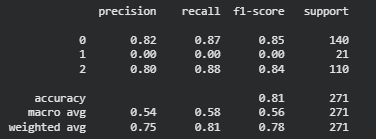

In [107]:
print(
    classification_report(
        y_test,
        y_pred_rf    )
)

              precision    recall  f1-score   support

           0       0.92      0.91      0.92       140
           1       0.78      0.67      0.72        21
           2       0.88      0.91      0.89       110

    accuracy                           0.89       271
   macro avg       0.86      0.83      0.84       271
weighted avg       0.89      0.89      0.89       271



In [108]:
print(
    classification_report(
        y_test,
        y_predtest_xgb
    )
)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       140
           1       0.78      0.67      0.72        21
           2       0.87      0.92      0.89       110

    accuracy                           0.89       271
   macro avg       0.86      0.83      0.84       271
weighted avg       0.89      0.89      0.89       271



##En los tres modelos estoy obteniendo un resultado bastante decente, sin embargo se puede observar que hay algo de overfitting (en unos modelos más que en otros). Para la mejora, es buena idea mitigar el overfitting para los 3 modelos usando los hiperparámetros de cada modelo. Y aplicar la técnica de SMOTEEN para balancear mejor el set de datos